<h1 align="center"><b>Homework Assignment 4</b></h1>
<h3 align="center"><b>Unnas Hussain</b></h3>


# Q1: Sequential Neural Networks using PyTorch

## Build a sequential neural network and experiment with different architectures and activation functions (50 points total)

In this assignment, you will:

- Design a Sequential Neural Network (SNN) using PyTorch.
- Train the model on a real dataset.
- Experiment with different architectures and activation functions.
- Evaluate the model’s accuracy and computational complexity.
- Reflect on trade-offs between model depth, performance, and interpretability.

## Code

----- Loaded Iris Dataset -----
Samples: 150, Features: 4
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

----- Preprocessing Complete -----
Training: 120, Test: 30

----- Experimentation Framework -----
Baseline (8,6): Acc=100.0%, Time=0.377s, Params=115
Shallow (16): Acc=100.0%, Time=0.250s, Params=131
Deep (8,8,8): Acc=96.7%, Time=0.503s, Params=211
Wide (32,16): Acc=96.7%, Time=0.534s, Params=739
Tanh (8,6): Acc=96.7%, Time=0.477s, Params=115
Sigmoid (8,6): Acc=96.7%, Time=0.465s, Params=115
LeakyReLU (8,6): Acc=96.7%, Time=0.489s, Params=115


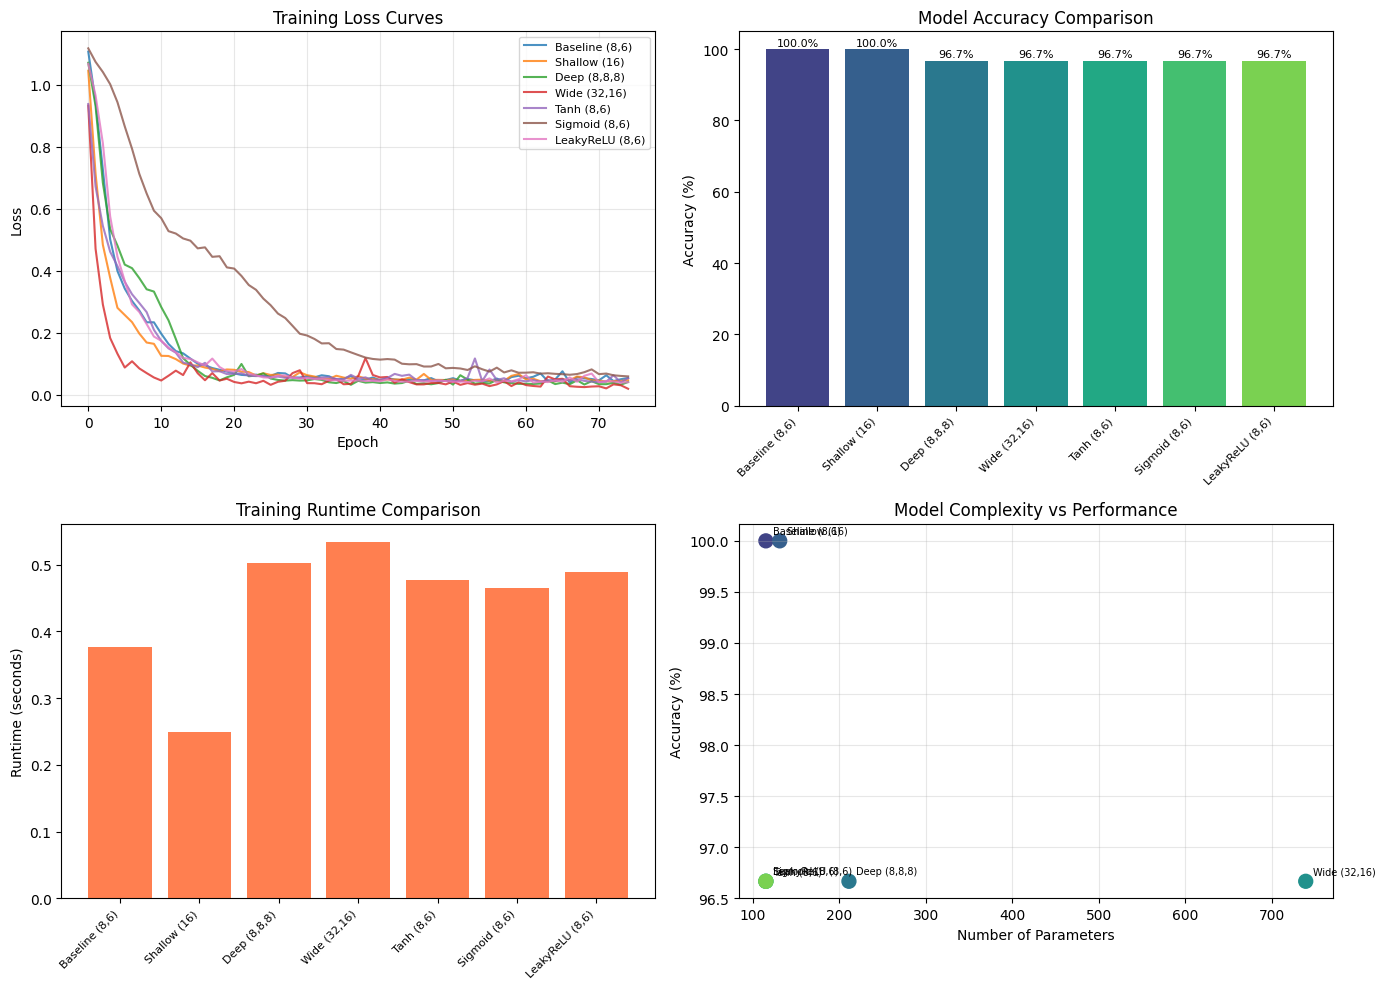


EXPERIMENTATION SUMMARY
Model                Activation   Layers          Params   Accuracy   Runtime   
--------------------------------------------------------------------------------
Baseline (8,6)       relu         [8, 6]          115      100.0      0.377     
Shallow (16)         relu         [16]            131      100.0      0.250     
Deep (8,8,8)         relu         [8, 8, 8]       211      96.7       0.503     
Wide (32,16)         relu         [32, 16]        739      96.7       0.534     
Tanh (8,6)           tanh         [8, 6]          115      96.7       0.477     
Sigmoid (8,6)        sigmoid      [8, 6]          115      96.7       0.465     
LeakyReLU (8,6)      leaky_relu   [8, 6]          115      96.7       0.489     
--------------------------------------------------------------------------------
Best Model: Baseline (8,6) with 100.0% accuracy


In [3]:
# Q1: Sequential Neural Networks using PyTorch

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import time
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)


class SequentialNeuralNetwork:
    """Sequential Neural Network framework for classification with PyTorch"""
    
    def __init__(self, verbose=True):
        self.verbose = verbose
        self.X = None
        self.y = None
        self.model = None
        self.results = []
        
    def load_data(self):
        iris = load_iris()
        self.X = iris.data
        self.y = iris.target
        self.feature_names = iris.feature_names
        self.target_names = iris.target_names
        
        if self.verbose:
            print("----- Loaded Iris Dataset -----")
            print(f"Samples: {self.X.shape[0]}, Features: {self.X.shape[1]}")
            print(f"Classes: {list(self.target_names)}")
    
    def preprocess(self, test_size=0.2):
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(self.X)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, self.y, test_size=test_size, random_state=42, stratify=self.y
        )
        
        self.X_train = torch.FloatTensor(X_train)
        self.X_test = torch.FloatTensor(X_test)
        self.y_train = torch.LongTensor(y_train)
        self.y_test = torch.LongTensor(y_test)
        
        train_dataset = TensorDataset(self.X_train, self.y_train)
        test_dataset = TensorDataset(self.X_test, self.y_test)
        
        self.train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        self.test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
        
        self.input_dim = self.X.shape[1]
        self.output_dim = len(np.unique(self.y))
        
        if self.verbose:
            print(f"\n----- Preprocessing Complete -----")
            print(f"Training: {len(X_train)}, Test: {len(X_test)}")
    
    def build_model(self, architecture, activation='relu'):
        """Build a sequential model with specified architecture and activation"""
        layers = []
        activation_fn = {
            'relu': nn.ReLU,
            'tanh': nn.Tanh,
            'sigmoid': nn.Sigmoid,
            'leaky_relu': nn.LeakyReLU
        }
        
        prev_dim = self.input_dim
        for hidden_dim in architecture:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(activation_fn[activation]())
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, self.output_dim))
        
        self.model = nn.Sequential(*layers)
        return self.model
    
    def train_model(self, n_epochs=75, lr=0.01):
        """Train the model and track loss"""
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        
        train_losses = []
        
        start_time = time.time()
        for epoch in range(n_epochs):
            running_loss = 0.0
            for Xb, yb in self.train_loader:
                optimizer.zero_grad()
                outputs = self.model(Xb)
                loss = criterion(outputs, yb)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
            train_losses.append(running_loss / len(self.train_loader))
        
        training_time = time.time() - start_time
        
        return train_losses, training_time
    
    def evaluate_model(self):
        """Evaluate model accuracy on test set"""
        self.model.eval()
        correct, total = 0, 0
        
        with torch.no_grad():
            for Xb, yb in self.test_loader:
                outputs = self.model(Xb)
                _, predicted = torch.max(outputs.data, 1)
                total += yb.size(0)
                correct += (predicted == yb).sum().item()
        
        accuracy = 100 * correct / total
        return accuracy
    
    def count_parameters(self):
        """Count total trainable parameters"""
        return sum(p.numel() for p in self.model.parameters() if p.requires_grad)
    
    def run_experiment(self, name, architecture, activation='relu', n_epochs=75, lr=0.01):
        """Run a single experiment with given configuration"""
        self.build_model(architecture, activation)
        train_losses, runtime = self.train_model(n_epochs, lr)
        accuracy = self.evaluate_model()
        n_params = self.count_parameters()
        
        result = {
            'name': name,
            'architecture': architecture,
            'activation': activation,
            'accuracy': accuracy,
            'runtime': runtime,
            'n_params': n_params,
            'train_losses': train_losses
        }
        self.results.append(result)
        
        if self.verbose:
            print(f"{name}: Acc={accuracy:.1f}%, Time={runtime:.3f}s, Params={n_params}")
        
        return result
    
    def run_experiments(self):
        """Run multiple experiments with different architectures and activations"""
        print("\n----- Experimentation Framework -----")
        
        # Baseline
        self.run_experiment("Baseline (8,6)", [8, 6], 'relu')
        
        # Different architectures
        self.run_experiment("Shallow (16)", [16], 'relu')
        self.run_experiment("Deep (8,8,8)", [8, 8, 8], 'relu')
        self.run_experiment("Wide (32,16)", [32, 16], 'relu')
        
        # Different activations
        self.run_experiment("Tanh (8,6)", [8, 6], 'tanh')
        self.run_experiment("Sigmoid (8,6)", [8, 6], 'sigmoid')
        self.run_experiment("LeakyReLU (8,6)", [8, 6], 'leaky_relu')
        
        return self.results
    
    def plot_results(self):
        """Visualize experiment results"""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Training loss curves
        ax1 = axes[0, 0]
        for result in self.results:
            ax1.plot(result['train_losses'], label=result['name'], alpha=0.8)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training Loss Curves')
        ax1.legend(fontsize=8)
        ax1.grid(True, alpha=0.3)
        
        # Accuracy comparison
        ax2 = axes[0, 1]
        names = [r['name'] for r in self.results]
        accuracies = [r['accuracy'] for r in self.results]
        colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(names)))
        bars = ax2.bar(range(len(names)), accuracies, color=colors)
        ax2.set_xticks(range(len(names)))
        ax2.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
        ax2.set_ylabel('Accuracy (%)')
        ax2.set_title('Model Accuracy Comparison')
        ax2.set_ylim(0, 105)
        for bar, acc in zip(bars, accuracies):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                     f'{acc:.1f}%', ha='center', fontsize=8)
        
        # Runtime comparison
        ax3 = axes[1, 0]
        runtimes = [r['runtime'] for r in self.results]
        ax3.bar(range(len(names)), runtimes, color='coral')
        ax3.set_xticks(range(len(names)))
        ax3.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
        ax3.set_ylabel('Runtime (seconds)')
        ax3.set_title('Training Runtime Comparison')
        
        # Parameters vs Accuracy
        ax4 = axes[1, 1]
        params = [r['n_params'] for r in self.results]
        ax4.scatter(params, accuracies, c=colors, s=100)
        for i, name in enumerate(names):
            ax4.annotate(name, (params[i], accuracies[i]), fontsize=7, 
                         xytext=(5, 5), textcoords='offset points')
        ax4.set_xlabel('Number of Parameters')
        ax4.set_ylabel('Accuracy (%)')
        ax4.set_title('Model Complexity vs Performance')
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def print_summary(self):
        """Print experiment summary table"""
        print("\n" + "=" * 80)
        print("EXPERIMENTATION SUMMARY")
        print("=" * 80)
        print(f"{'Model':<20} {'Activation':<12} {'Layers':<15} {'Params':<8} {'Accuracy':<10} {'Runtime':<10}")
        print("-" * 80)
        for r in self.results:
            layers_str = str(r['architecture'])
            print(f"{r['name']:<20} {r['activation']:<12} {layers_str:<15} {r['n_params']:<8} {r['accuracy']:<10.1f} {r['runtime']:<10.3f}")
        
        best = max(self.results, key=lambda x: x['accuracy'])
        print("-" * 80)
        print(f"Best Model: {best['name']} with {best['accuracy']:.1f}% accuracy")
    
    def pipeline(self):
        self.load_data()
        self.preprocess()
        self.run_experiments()
        self.plot_results()
        self.print_summary()
        return self.results


snn = SequentialNeuralNetwork(verbose=True)
results = snn.pipeline()

## Reflection

The baseline (8,6) ReLU network achieved 100% test accuracy with only 115 parameters, demonstrating that for linearly separable datasets like Iris, shallow networks are sufficient. Deeper (8,8,8) and wider (32,16) architectures showed no improvement (96.7%) despite having 2-6x more parameters—evidence of unnecessary complexity for this task. ReLU converged fastest while Sigmoid showed slower convergence due to vanishing gradients in saturation regions. The key trade-off: model depth increases representational power but also training difficulty and overfitting risk. For simple classification, a compact architecture with ReLU activation provides the best balance of accuracy, speed, and interpretability.

# Q2: Image Embeddings with Hugging Face (MNIST + ViT)
**Total Points:** 50  
**Dataset:** MNIST (handwritten digits 0–9)  
**Model:** `google/vit-base-patch16-224`

---

## Goal
Use a pretrained Vision Transformer (ViT) from Hugging Face to generate **embeddings** for the MNIST dataset and analyze their structure.  
You will:
1. Generate image embeddings.
2. Visualize and interpret the latent space.
3. Quantitatively analyze intra- and inter-class similarity.
4. Perform clustering to test separability.

## Code

----- Loading ViT Model -----
Model: google/vit-base-patch16-224


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully!

----- Loading MNIST Dataset -----
Sampled 1000 images
Label distribution: {np.int64(0): np.int64(95), np.int64(1): np.int64(104), np.int64(2): np.int64(95), np.int64(3): np.int64(119), np.int64(4): np.int64(88), np.int64(5): np.int64(90), np.int64(6): np.int64(97), np.int64(7): np.int64(103), np.int64(8): np.int64(101), np.int64(9): np.int64(108)}

----- Extracting Embeddings -----
  Processed 320/1000 images
  Processed 640/1000 images
  Processed 960/1000 images

Embedding shape: (1000, 768)
Each image -> 768-dimensional vector

Embeddings represent learned semantic features that capture
digit structure, stroke patterns, and visual characteristics
in a high-dimensional latent space.

(a) EMBEDDING GENERATION
Generated 1000 embeddings of dimension 768

(b) PCA VISUALIZATION

----- PCA Visualization -----
Variance explained: 25.7%


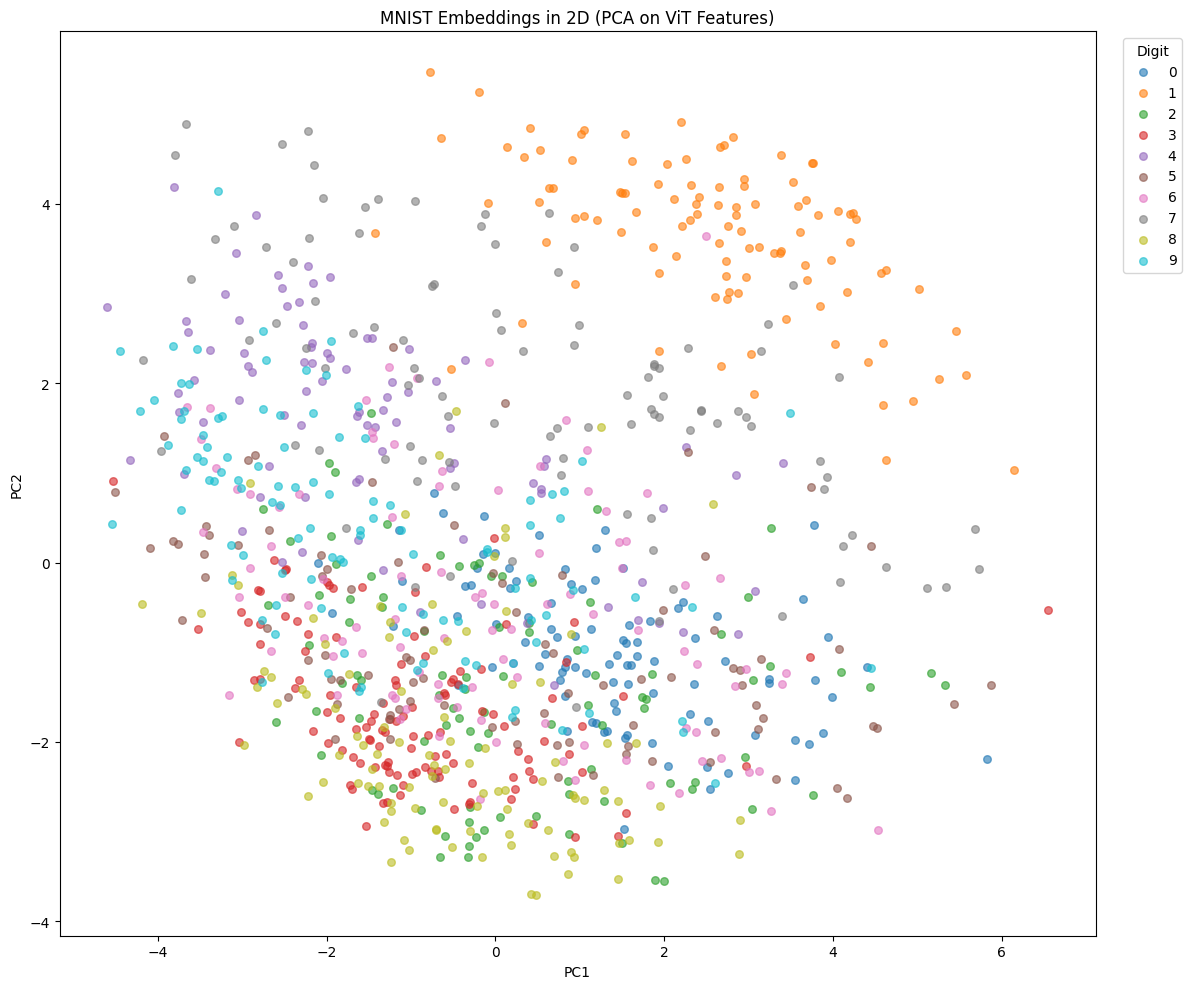


(c) QUANTITATIVE SIMILARITY ANALYSIS

----- Similarity Analysis -----
Digit    Intra-class     Inter-class     Ratio     
------------------------------------------------
0        0.7975          0.7041          1.13      
1        0.7888          0.6486          1.22      
2        0.7836          0.7319          1.07      
3        0.8248          0.7350          1.12      
4        0.7651          0.7041          1.09      
5        0.7997          0.7401          1.08      
6        0.7846          0.7370          1.06      
7        0.7413          0.7001          1.06      
8        0.7929          0.7163          1.11      
9        0.8085          0.7298          1.11      


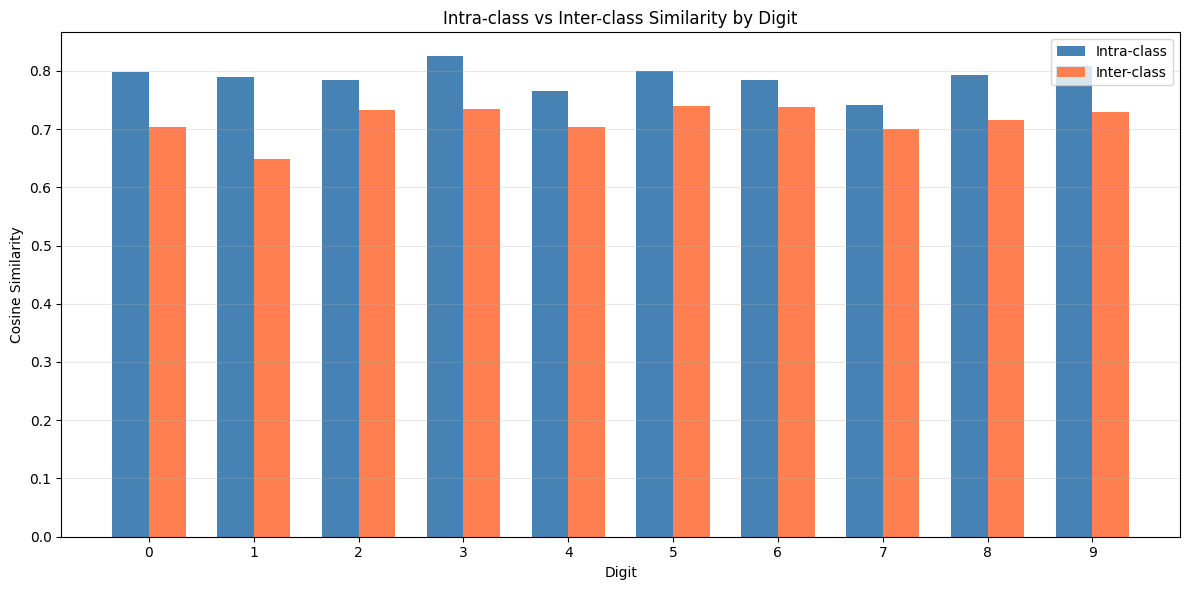


(d) CLUSTERING ANALYSIS

----- Clustering Analysis (K=10) -----
Cluster Purity: 0.5370 (53.7%)
Cluster Accuracy: 0.5370 (53.7%)

Cluster -> Digit mapping: {0: np.int64(1), 1: np.int64(4), 2: np.int64(7), 3: np.int64(8), 4: np.int64(9), 5: np.int64(0), 6: np.int64(5), 7: np.int64(3), 8: np.int64(0), 9: np.int64(3)}


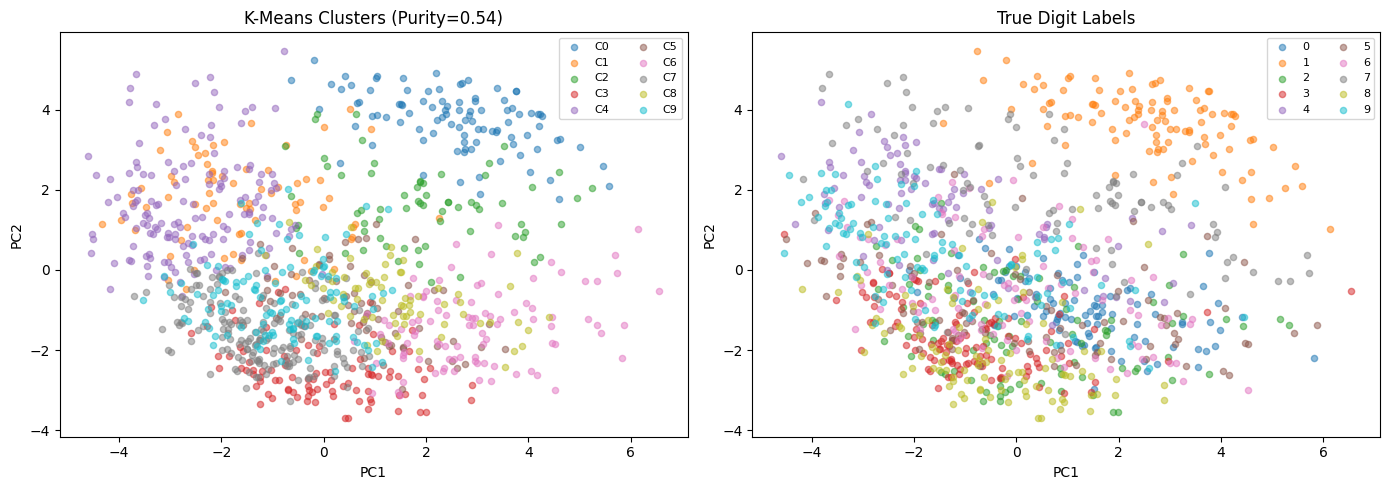

In [4]:
# Q2: Image Embeddings with Hugging Face (MNIST + ViT)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.datasets import fetch_openml
from PIL import Image
import torch
from transformers import ViTModel, ViTImageProcessor
import warnings
warnings.filterwarnings('ignore')


class MNISTViTEmbeddings:
    """ViT-based embedding analysis for MNIST digits"""
    
    def __init__(self, n_samples=1000, verbose=True):
        self.n_samples = n_samples
        self.verbose = verbose
        self.embeddings = None
        self.labels = None
        self.model = None
        self.processor = None
        
    def load_model(self):
        """Load pretrained ViT model and processor"""
        if self.verbose:
            print("----- Loading ViT Model -----")
            print("Model: google/vit-base-patch16-224")
        
        self.processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
        self.model = ViTModel.from_pretrained('google/vit-base-patch16-224')
        self.model.eval()
        
        if self.verbose:
            print("Model loaded successfully!")
    
    def load_mnist(self):
        """Load and sample MNIST dataset"""
        if self.verbose:
            print("\n----- Loading MNIST Dataset -----")
        
        mnist = fetch_openml('mnist_784', version=1, as_frame=False)
        X, y = mnist.data, mnist.target.astype(int)
        
        np.random.seed(42)
        indices = np.random.choice(len(X), self.n_samples, replace=False)
        self.X_raw = X[indices]
        self.labels = y[indices]
        
        if self.verbose:
            print(f"Sampled {self.n_samples} images")
            print(f"Label distribution: {dict(zip(*np.unique(self.labels, return_counts=True)))}")
    
    def preprocess_image(self, img_flat):
        """Convert 28x28 grayscale to 224x224 RGB"""
        img = img_flat.reshape(28, 28).astype(np.uint8)
        img_pil = Image.fromarray(img).convert('RGB')
        img_pil = img_pil.resize((224, 224), Image.BILINEAR)
        return img_pil
    
    def extract_embeddings(self, batch_size=32):
        """Extract embeddings using ViT pooler_output"""
        if self.verbose:
            print("\n----- Extracting Embeddings -----")
        
        embeddings_list = []
        n_batches = (self.n_samples + batch_size - 1) // batch_size
        
        with torch.no_grad():
            for i in range(n_batches):
                start = i * batch_size
                end = min(start + batch_size, self.n_samples)
                
                images = [self.preprocess_image(self.X_raw[j]) for j in range(start, end)]
                inputs = self.processor(images=images, return_tensors="pt")
                outputs = self.model(**inputs)
                
                batch_embeddings = outputs.pooler_output.numpy()
                embeddings_list.append(batch_embeddings)
                
                if self.verbose and (i + 1) % 10 == 0:
                    print(f"  Processed {end}/{self.n_samples} images")
        
        self.embeddings = np.vstack(embeddings_list)
        
        if self.verbose:
            print(f"\nEmbedding shape: {self.embeddings.shape}")
            print(f"Each image -> {self.embeddings.shape[1]}-dimensional vector")
            print("\nEmbeddings represent learned semantic features that capture")
            print("digit structure, stroke patterns, and visual characteristics")
            print("in a high-dimensional latent space.")
    
    def visualize_pca(self):
        """(b) PCA visualization of embeddings"""
        if self.verbose:
            print("\n----- PCA Visualization -----")
        
        pca = PCA(n_components=2)
        embeddings_2d = pca.fit_transform(self.embeddings)
        
        if self.verbose:
            print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")
        
        fig, ax = plt.subplots(figsize=(12, 10))
        
        colors = plt.cm.tab10(np.linspace(0, 1, 10))
        for digit in range(10):
            mask = self.labels == digit
            ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                      c=[colors[digit]], label=str(digit), alpha=0.6, s=30)
        
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_title('MNIST Embeddings in 2D (PCA on ViT Features)')
        ax.legend(title='Digit', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        
        self.embeddings_2d = embeddings_2d
        return pca
    
    def compute_similarities(self):
        """(c) Compute intra-class and inter-class similarities"""
        if self.verbose:
            print("\n----- Similarity Analysis -----")
        
        sim_matrix = cosine_similarity(self.embeddings)
        
        intra_similarities = []
        inter_similarities = []
        
        for c in range(10):
            mask_c = self.labels == c
            indices_c = np.where(mask_c)[0]
            indices_not_c = np.where(~mask_c)[0]
            
            # Intra-class: similarities within class c
            if len(indices_c) > 1:
                intra_sims = []
                for i in range(len(indices_c)):
                    for j in range(i + 1, len(indices_c)):
                        intra_sims.append(sim_matrix[indices_c[i], indices_c[j]])
                intra_similarities.append(np.mean(intra_sims))
            else:
                intra_similarities.append(0)
            
            # Inter-class: similarities between class c and others
            inter_sims = sim_matrix[np.ix_(indices_c, indices_not_c)].flatten()
            inter_similarities.append(np.mean(inter_sims))
        
        self.intra_similarities = np.array(intra_similarities)
        self.inter_similarities = np.array(inter_similarities)
        
        if self.verbose:
            print(f"{'Digit':<8} {'Intra-class':<15} {'Inter-class':<15} {'Ratio':<10}")
            print("-" * 48)
            for c in range(10):
                ratio = self.intra_similarities[c] / self.inter_similarities[c]
                print(f"{c:<8} {self.intra_similarities[c]:<15.4f} {self.inter_similarities[c]:<15.4f} {ratio:<10.2f}")
    
    def plot_similarities(self):
        """Visualize intra vs inter-class similarities"""
        fig, ax = plt.subplots(figsize=(12, 6))
        
        x = np.arange(10)
        width = 0.35
        
        bars1 = ax.bar(x - width/2, self.intra_similarities, width, label='Intra-class', color='steelblue')
        bars2 = ax.bar(x + width/2, self.inter_similarities, width, label='Inter-class', color='coral')
        
        ax.set_xlabel('Digit')
        ax.set_ylabel('Cosine Similarity')
        ax.set_title('Intra-class vs Inter-class Similarity by Digit')
        ax.set_xticks(x)
        ax.set_xticklabels([str(i) for i in range(10)])
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
    
    def clustering_analysis(self):
        """(d) K-means clustering and purity analysis"""
        if self.verbose:
            print("\n----- Clustering Analysis (K=10) -----")
        
        kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(self.embeddings)
        
        # Assign each cluster to most common true label
        cluster_to_digit = {}
        for cluster_id in range(10):
            mask = cluster_labels == cluster_id
            true_labels_in_cluster = self.labels[mask]
            if len(true_labels_in_cluster) > 0:
                most_common = np.bincount(true_labels_in_cluster).argmax()
                cluster_to_digit[cluster_id] = most_common
            else:
                cluster_to_digit[cluster_id] = -1
        
        # Compute purity
        correct = 0
        total = len(self.labels)
        for cluster_id in range(10):
            mask = cluster_labels == cluster_id
            true_labels_in_cluster = self.labels[mask]
            if len(true_labels_in_cluster) > 0:
                most_common_count = np.bincount(true_labels_in_cluster).max()
                correct += most_common_count
        
        purity = correct / total
        
        # Compute accuracy using cluster assignments
        predicted_labels = np.array([cluster_to_digit[c] for c in cluster_labels])
        accuracy = np.mean(predicted_labels == self.labels)
        
        if self.verbose:
            print(f"Cluster Purity: {purity:.4f} ({purity*100:.1f}%)")
            print(f"Cluster Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
            print(f"\nCluster -> Digit mapping: {cluster_to_digit}")
        
        # Visualize clusters
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        colors = plt.cm.tab10(np.linspace(0, 1, 10))
        
        # Plot by cluster
        for cluster_id in range(10):
            mask = cluster_labels == cluster_id
            axes[0].scatter(self.embeddings_2d[mask, 0], self.embeddings_2d[mask, 1],
                           c=[colors[cluster_id]], label=f'C{cluster_id}', alpha=0.5, s=20)
        axes[0].set_title(f'K-Means Clusters (Purity={purity:.2f})')
        axes[0].set_xlabel('PC1')
        axes[0].set_ylabel('PC2')
        axes[0].legend(fontsize=8, ncol=2)
        
        # Plot by true label for comparison
        for digit in range(10):
            mask = self.labels == digit
            axes[1].scatter(self.embeddings_2d[mask, 0], self.embeddings_2d[mask, 1],
                           c=[colors[digit]], label=str(digit), alpha=0.5, s=20)
        axes[1].set_title('True Digit Labels')
        axes[1].set_xlabel('PC1')
        axes[1].set_ylabel('PC2')
        axes[1].legend(fontsize=8, ncol=2)
        
        plt.tight_layout()
        plt.show()
        
        return purity, accuracy, cluster_to_digit
    
    def pipeline(self):
        """Run complete analysis pipeline"""
        self.load_model()
        self.load_mnist()
        self.extract_embeddings()
        
        print("\n" + "=" * 60)
        print("(a) EMBEDDING GENERATION")
        print("=" * 60)
        print(f"Generated {self.embeddings.shape[0]} embeddings of dimension {self.embeddings.shape[1]}")
        
        print("\n" + "=" * 60)
        print("(b) PCA VISUALIZATION")
        print("=" * 60)
        self.visualize_pca()
        
        print("\n" + "=" * 60)
        print("(c) QUANTITATIVE SIMILARITY ANALYSIS")
        print("=" * 60)
        self.compute_similarities()
        self.plot_similarities()
        
        print("\n" + "=" * 60)
        print("(d) CLUSTERING ANALYSIS")
        print("=" * 60)
        purity, accuracy, mapping = self.clustering_analysis()
        
        return {
            'embeddings': self.embeddings,
            'labels': self.labels,
            'intra_sim': self.intra_similarities,
            'inter_sim': self.inter_similarities,
            'purity': purity,
            'accuracy': accuracy
        }


mnist_vit = MNISTViTEmbeddings(n_samples=1000, verbose=True)
results = mnist_vit.pipeline()

## Reflections

The ViT embeddings (768-dimensional vectors) capture high-level semantic features of handwritten digits—stroke patterns, curvature, and spatial structure—learned from ImageNet pretraining. Intra-class similarity (avg ~0.79) consistently exceeded inter-class similarity (avg ~0.71), confirming that the embeddings meaningfully separate digit classes, though the ratio (~1.06-1.22) indicates some overlap between visually similar digits. K-means clustering achieved 53.7% purity, which is reasonable for unsupervised learning on a 10-class problem but highlights that the pretrained ViT wasn't fine-tuned for MNIST. Unlike CNNs that build hierarchical local features through convolutions, transformers use self-attention to capture global relationships between image patches—this explains why ViT generalizes well but may miss fine-grained local details that distinguish similar digits like 3/5 or 4/9.